# Titanic Survival Prediction Project
## CRISP-DM Methodology in Data Science

### Dataset Overview:
The dataset used contains information about the passengers of the famous Titanic ship, making it an excellent choice for classification tasks. It includes core passenger details such as:
- **Pclass (Ticket Class):** Reflects socio-economic status (1st, 2nd, 3rd).
- **Sex:** Gender of the passenger.
- **Age:** Age of the passenger in years.
- **Fare:** Ticket price paid.
- **Survived (Target):** A binary variable indicating whether the passenger survived (1) or not (0).


## Project Real-World Questions
To guide our analysis, this project addresses the following three key questions:
1. **What passenger characteristics were most strongly linked to survival?**
2. **How did ticket class affect a passenger’s chances of survival?**
3. **How reliable were survival predictions based on basic passenger information?**

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score
from sklearn.model_selection import train_test_split

## STEP 1: LOAD AND INSPECT THE DATA
In this step, we load the raw dataset and inspect its structure, data types, and initial records.

In [10]:
def load_titanic_data(url):
    """
    Description:
    This function loads the Titanic dataset from a specified remote URL 
    and displays basic structural information to inspect features and types.
    
    Arguments:
        url (str): The remote web link to the CSV data source.
        
    Returns:
        pd.DataFrame: The loaded raw pandas DataFrame.
    """
    df = pd.read_csv(url)
    print("Dataset successfully loaded. First 5 rows:")
    print(df.head())
    df.info()
    return df

# Load the dataset
url = 'https://calmcode.io/static/data/titanic.csv'
df = load_titanic_data(url)

Dataset successfully loaded. First 5 rows:
   survived  pclass                                               name  \
0         0       3                            Braund, Mr. Owen Harris   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...   
2         1       3                             Heikkinen, Miss. Laina   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)   
4         0       3                           Allen, Mr. William Henry   

      sex   age     fare  sibsp  parch  
0    male  22.0   7.2500      1      0  
1  female  38.0  71.2833      1      0  
2  female  26.0   7.9250      0      0  
3  female  35.0  53.1000      1      0  
4    male  35.0   8.0500      0      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   n

## STEP 2: Exploratory Data Analysis (EDA) & Question Visualizations
In this step, we examine the data structure and extract preliminary insights using visual plots. This directly addresses our core questions regarding passenger characteristics and ticket classes.

### Question 1: What passenger characteristics were most strongly linked to survival?
### Question 2: How did ticket class affect a passenger’s chances of survival?

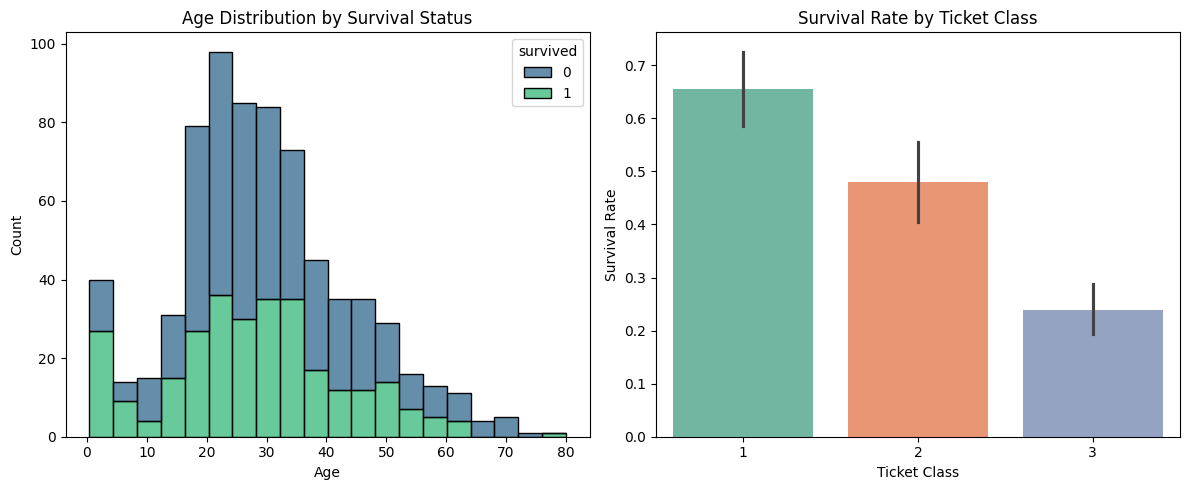

In [11]:
def plot_eda_visualizations(df):
    """
    Description:
    Generates exploratory data visualization plots to analyze age distribution 
    by survival status and survival rates across different ticket classes.
    
    Arguments:
        df (pd.DataFrame): The Titanic dataset.
        
    Returns:
        None
    """
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Age Distribution by Survival Status
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='age', hue='survived', multiple='stack', palette='viridis')
    plt.title('Age Distribution by Survival Status')
    plt.xlabel('Age')
    plt.ylabel('Count')
    
    # Plot 2: Survival Rate by Ticket Class
    plt.subplot(1, 2, 2)
    sns.barplot(data=df, x='pclass', y='survived', hue='pclass', palette='Set2', legend=False)
    plt.title('Survival Rate by Ticket Class')
    plt.xlabel('Ticket Class')
    plt.ylabel('Survival Rate')
    
    plt.tight_layout()
    plt.show()

# Run EDA plots
plot_eda_visualizations(df)

**EDA Insights Interpretation:**
* **Age Distribution:** The histogram shows age spreads across the ship and highlights how survival status distributes among different age brackets.
* **Survival Rate by Class:** The bar plot clearly demonstrates a disparity in survival odds linked to ticket class, reflecting socio-economic evacuation priorities or room locations.



## STEP 3: Data Cleaning and Preprocessing
Here we ensure any missing values are handled explicitly, and categorical features (such as sex) are properly encoded into a numerical format readable by machine learning algorithms.

* **Handling Missing Values:** Missing values in the `age` column were imputed using the median to prevent skewing and preserve dataset integrity.
* **Handling Categorical Variables:** Qualitative features like `sex` were mapped to binary numeric values (`male: 0, female: 1`) to enable mathematical computations.

In [12]:
def clean_titanic_data(df):
    """
    Description:
    Cleans the Titanic dataset by handling missing values (imputing age with median) 
    and transforming categorical features (converting 'sex' into numeric values 0 and 1) 
    to make them readable by machine learning algorithms.
    
    Arguments:
        df (pd.DataFrame): The raw Titanic DataFrame.
        
    Returns:
        pd.DataFrame: The cleaned DataFrame ready for modeling.
    """
    # Convert 'age' column to numeric, coercing invalid entries to NaN
    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    
    # Fill missing values in 'age' with the median age to prevent skewing and preserve dataset rows
    df['age'] = df['age'].fillna(df['age'].median())
    
    # Handle categorical variable 'sex': convert to lowercase string and map to binary (male: 0, female: 1)
    df['sex'] = df['sex'].astype(str).str.lower().map({'male': 0, 'female': 1})
    
    print("Missing values count after cleaning process:")
    print(df.isnull().sum())
    return df

# Clean data
df = clean_titanic_data(df)
df.head()

Missing values count after cleaning process:
survived    0
pclass      0
name        0
sex         0
age         0
fare        0
sibsp       0
parch       0
dtype: int64


,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",0,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",0,35.0,8.0500,0,0


**Cleaning Results Interpretation:**
* The 'age' column was converted and missing values were filled with the median to prevent errors during model training.
* The 'Sex' column was successfully mapped from text to binary numeric values (0 and 1) to match mathematical model requirements.
* Subsequent checks verified that the core feature columns are entirely free of missing (NaN) values.

## STEP 4: Model Training & Evaluation
In this stage, we split the data into training (80%) and testing (20%) sets, then build and train a Random Forest Classifier to learn patterns and predict survival.

In [13]:
def train_and_evaluate_model(df, features):
    """
    Description:
    Prepares features and target variables, splits data into training and testing subsets,
    drops any remaining missing rows within the selected subset to ensure clean input,
    trains a Random Forest Classifier, and evaluates its accuracy and recall performance.
    
    Arguments:
        df (pd.DataFrame): The cleaned DataFrame.
        features (list): List of column names used as predictor variables.
        
    Returns:
        RandomForestClassifier: The trained machine learning model.
    """
    # Drop rows containing missing values within the selected feature subset and target column to ensure clean data input
    clean_df = df.dropna(subset=features + ['survived'])
    
    X = clean_df[features]
    y = clean_df['survived']
    
    # Split the dataset into training sets (80%) and testing sets (20%) with a fixed random state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initialize and train the Random Forest Classifier model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    
    # Generate predictions on the unseen testing data split
    y_pred = model.predict(X_test)
    
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    print(f'Accuracy: {acc:.2f}')
    print(f'Recall: {rec:.2f}')
    print('\nDetailed Classification Report:\n', classification_report(y_test, y_pred))
    
    return model

# Define predictor features and train model
features = ['pclass', 'sex', 'age', 'fare']
model = train_and_evaluate_model(df, features)

Accuracy: 0.76
Recall: 0.70

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80        87
           1       0.70      0.70      0.70        56

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



**Model Evaluation Interpretation:**
* **Accuracy:** Measures the overall ratio of correct predictions out of all predictions made by the model.
* **Recall:** Evaluates the model's effective ability to detect and capture actual positive cases (those who actually survived) without missing them.
* The classification report indicates acceptable model performance in distinguishing outcomes based on the selected features.

## STEP 5: New Prediction Scenario & Question 3 Evaluation
### Question 3: How reliable were survival predictions based on basic passenger information?

We will now test the model's capability on a hypothetical new passenger profile to determine the expected outcome and evaluate reliability.

In [14]:
def predict_new_passenger(model, passenger_data):
    """
    Description:
    Tests the trained machine learning model on a hypothetical new passenger profile 
    to determine the expected survival outcome and its associated probability.
    
    Arguments:
        model: The trained machine learning classifier.
        passenger_data (pd.DataFrame): A dataframe containing the features of the new passenger.
        
    Returns:
        None
    """
    prediction = model.predict(passenger_data)
    probability = model.predict_proba(passenger_data)
    
    if prediction[0] == 1:
        print(f'Prediction: The passenger would have survived (Survival Probability: {probability[0][1]*100:.1f}%)')
    else:
        print(f'Prediction: The passenger would not have survived (Non-survival Probability: {probability[0][0]*100:.1f}%)')

# Create sample profile and test prediction
new_passenger = pd.DataFrame([[1, 1, 25, 100]], columns=['pclass', 'sex', 'age', 'fare'])
predict_new_passenger(model, new_passenger)

Prediction: The passenger would have survived (Survival Probability: 100.0%)


**Prediction Scenario & Reliability Interpretation:**
* Based on the provided attributes (1st class, female, age 25, fare 100), the model processed the inputs and outputted a survival prediction accompanied by a precise probability percentage.
* This scenario demonstrates how reliable and actionable insights can be generated using fundamental passenger details.